In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from metrics import ForecastingMetrics

## Kernel Ridge Regression Results
- Use a kernel Ridge regression model to predict index yields 7 days into the future
- Model predicts the E[Y | X] by using some kernel function to smooth out x and y

### Training:
- A growing training window, window starts at 2000
- Makes 31 predictions (Monthly) before every retrain
- Uses Time Sereis split Cross Validation with 3 folds and 60 tests under 4000 samples. 4 splits 100 test samples over 4000 splits. 5, 150 over 5000.
- selects best estimator, kernel and alpha parameter

### Prediction:
- Masks variables that are negative by randomly selecting a value between 0.01 and 0.001
- Extreme positives, if the prediction is more than a random sample between the training periods 3rd and 4.2 standard deviations away, clip the value to that random variable.
-

In [ ]:
%%sql


In [2]:
metric_forecaster = ForecastingMetrics(time_prediction='seven-day-ahead', actuals_file='data/fred_prorcessed_daily.parquet')

INFO:metrics:            DGS1MO  DGS3MO  DGS6MO  DGS1  DGS2  DGS3  DGS5  DGS7  DGS10  \
period                                                                    
2010-01-01    0.02    0.05    0.15  0.37  0.96  1.56  2.57  3.31   3.83   
2010-01-02    0.02    0.05    0.15  0.37  0.96  1.56  2.57  3.31   3.83   
2010-01-03    0.02    0.05    0.15  0.37  0.96  1.56  2.57  3.31   3.83   
2010-01-04    0.01    0.04    0.13  0.35  0.95  1.55  2.58  3.32   3.85   
2010-01-05    0.02    0.05    0.14  0.34  0.92  1.50  2.49  3.22   3.74   

            DGS20  DGS30  
period                    
2010-01-01   4.61   4.70  
2010-01-02   4.61   4.70  
2010-01-03   4.61   4.70  
2010-01-04   4.64   4.74  
2010-01-05   4.52   4.62  
100%|██████████| 4743/4743 [03:10<00:00, 24.86it/s]


In [3]:
# metric_forecaster
metric_forecaster.calculate_sample_metrics()
metric_forecaster.forecasts_df.head()

,date,DGS1MO_future_val_mean,DGS1MO_future_val_std,DGS1MO_future_val_min,DGS1MO_future_val_max,DGS1MO_future_val_97_5,DGS1MO_future_val_2_5,DGS3MO_future_val_mean,DGS3MO_future_val_std,DGS3MO_future_val_min,...,DGS5_sample_metric,DGS5_sample_range,DGS7_sample_metric,DGS7_sample_range,DGS10_sample_metric,DGS10_sample_range,DGS20_sample_metric,DGS20_sample_range,DGS30_sample_metric,DGS30_sample_range
0,2012-01-16,0.091683,0.051582,0.062821,0.360971,0.256023,0.062821,0.049906,0.046248,0.012197,...,within 1 std,within sample,Within 2 std,within sample,Surpasse sample boundary,out of sample,Surpasse sample boundary,out of sample,Surpasse sample boundary,out of sample
1,2012-12-05,0.121499,0.070538,0.046578,0.357131,0.279828,0.046578,0.127933,0.060415,0.004955,...,within 1 std,within sample,within 1 std,within sample,within 1 std,within sample,Within 2 std,within sample,Within 2 std,within sample
2,2020-05-16,0.104438,0.051877,0.034376,0.294811,0.208858,0.034376,0.126010,0.045861,0.009005,...,within 1 std,within sample,within 1 std,within sample,within 1 std,within sample,within 1 std,within sample,within 1 std,within sample
3,2015-11-27,0.088922,0.035300,0.085609,0.559698,0.096553,0.085609,0.063068,0.027458,0.060533,...,Surpasse sample boundary,out of sample,Surpasse sample boundary,out of sample,Surpasse sample boundary,out of sample,within 1 std,within sample,within 1 std,within sample
4,2015-02-24,0.069342,0.042079,0.034300,0.259147,0.157360,0.034300,0.055622,0.022904,0.037998,...,within 1 std,within sample,within 1 std,within sample,within 1 std,within sample,within 1 std,within sample,within 1 std,within sample


In [5]:
# metric_forecaster.plot_sample_metrics()

In [4]:
def plot_sample_metrics() -> None:
    """
    Create a stacked bar chart of sample metrics.
    Returns:

    """
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 17))
    axes = axes.flatten()
    color_palette ={
            "within 1 std": "#002F6C",
            "Within 2 std": "#398FFF",
            "Surpasse sample boundary": "#EB2254",
            "Greater than 2 std": "#EB2254"
        }
    for i, col in enumerate(metric_forecaster.actuals_variables):
        df_tmp = metric_forecaster.forecasts_df[[f"{col}_sample_range", f"{col}_sample_metric"]].value_counts().reset_index()

        sns.barplot(data=df_tmp,
                      x=f"{col}_sample_range",
                      y="count",
                      hue=f"{col}_sample_metric",
                      palette=color_palette,
                      ax=axes[i])
        axes[i].set_title(f'Sample Metrics for {col} - {metric_forecaster.time_prediction}')
        axes[i].set_xlabel('Sample Metric')
        axes[i].set_ylabel('Count')
        axes[i].legend(title='Sample Metric')
    plt.tight_layout()
    plt.show()

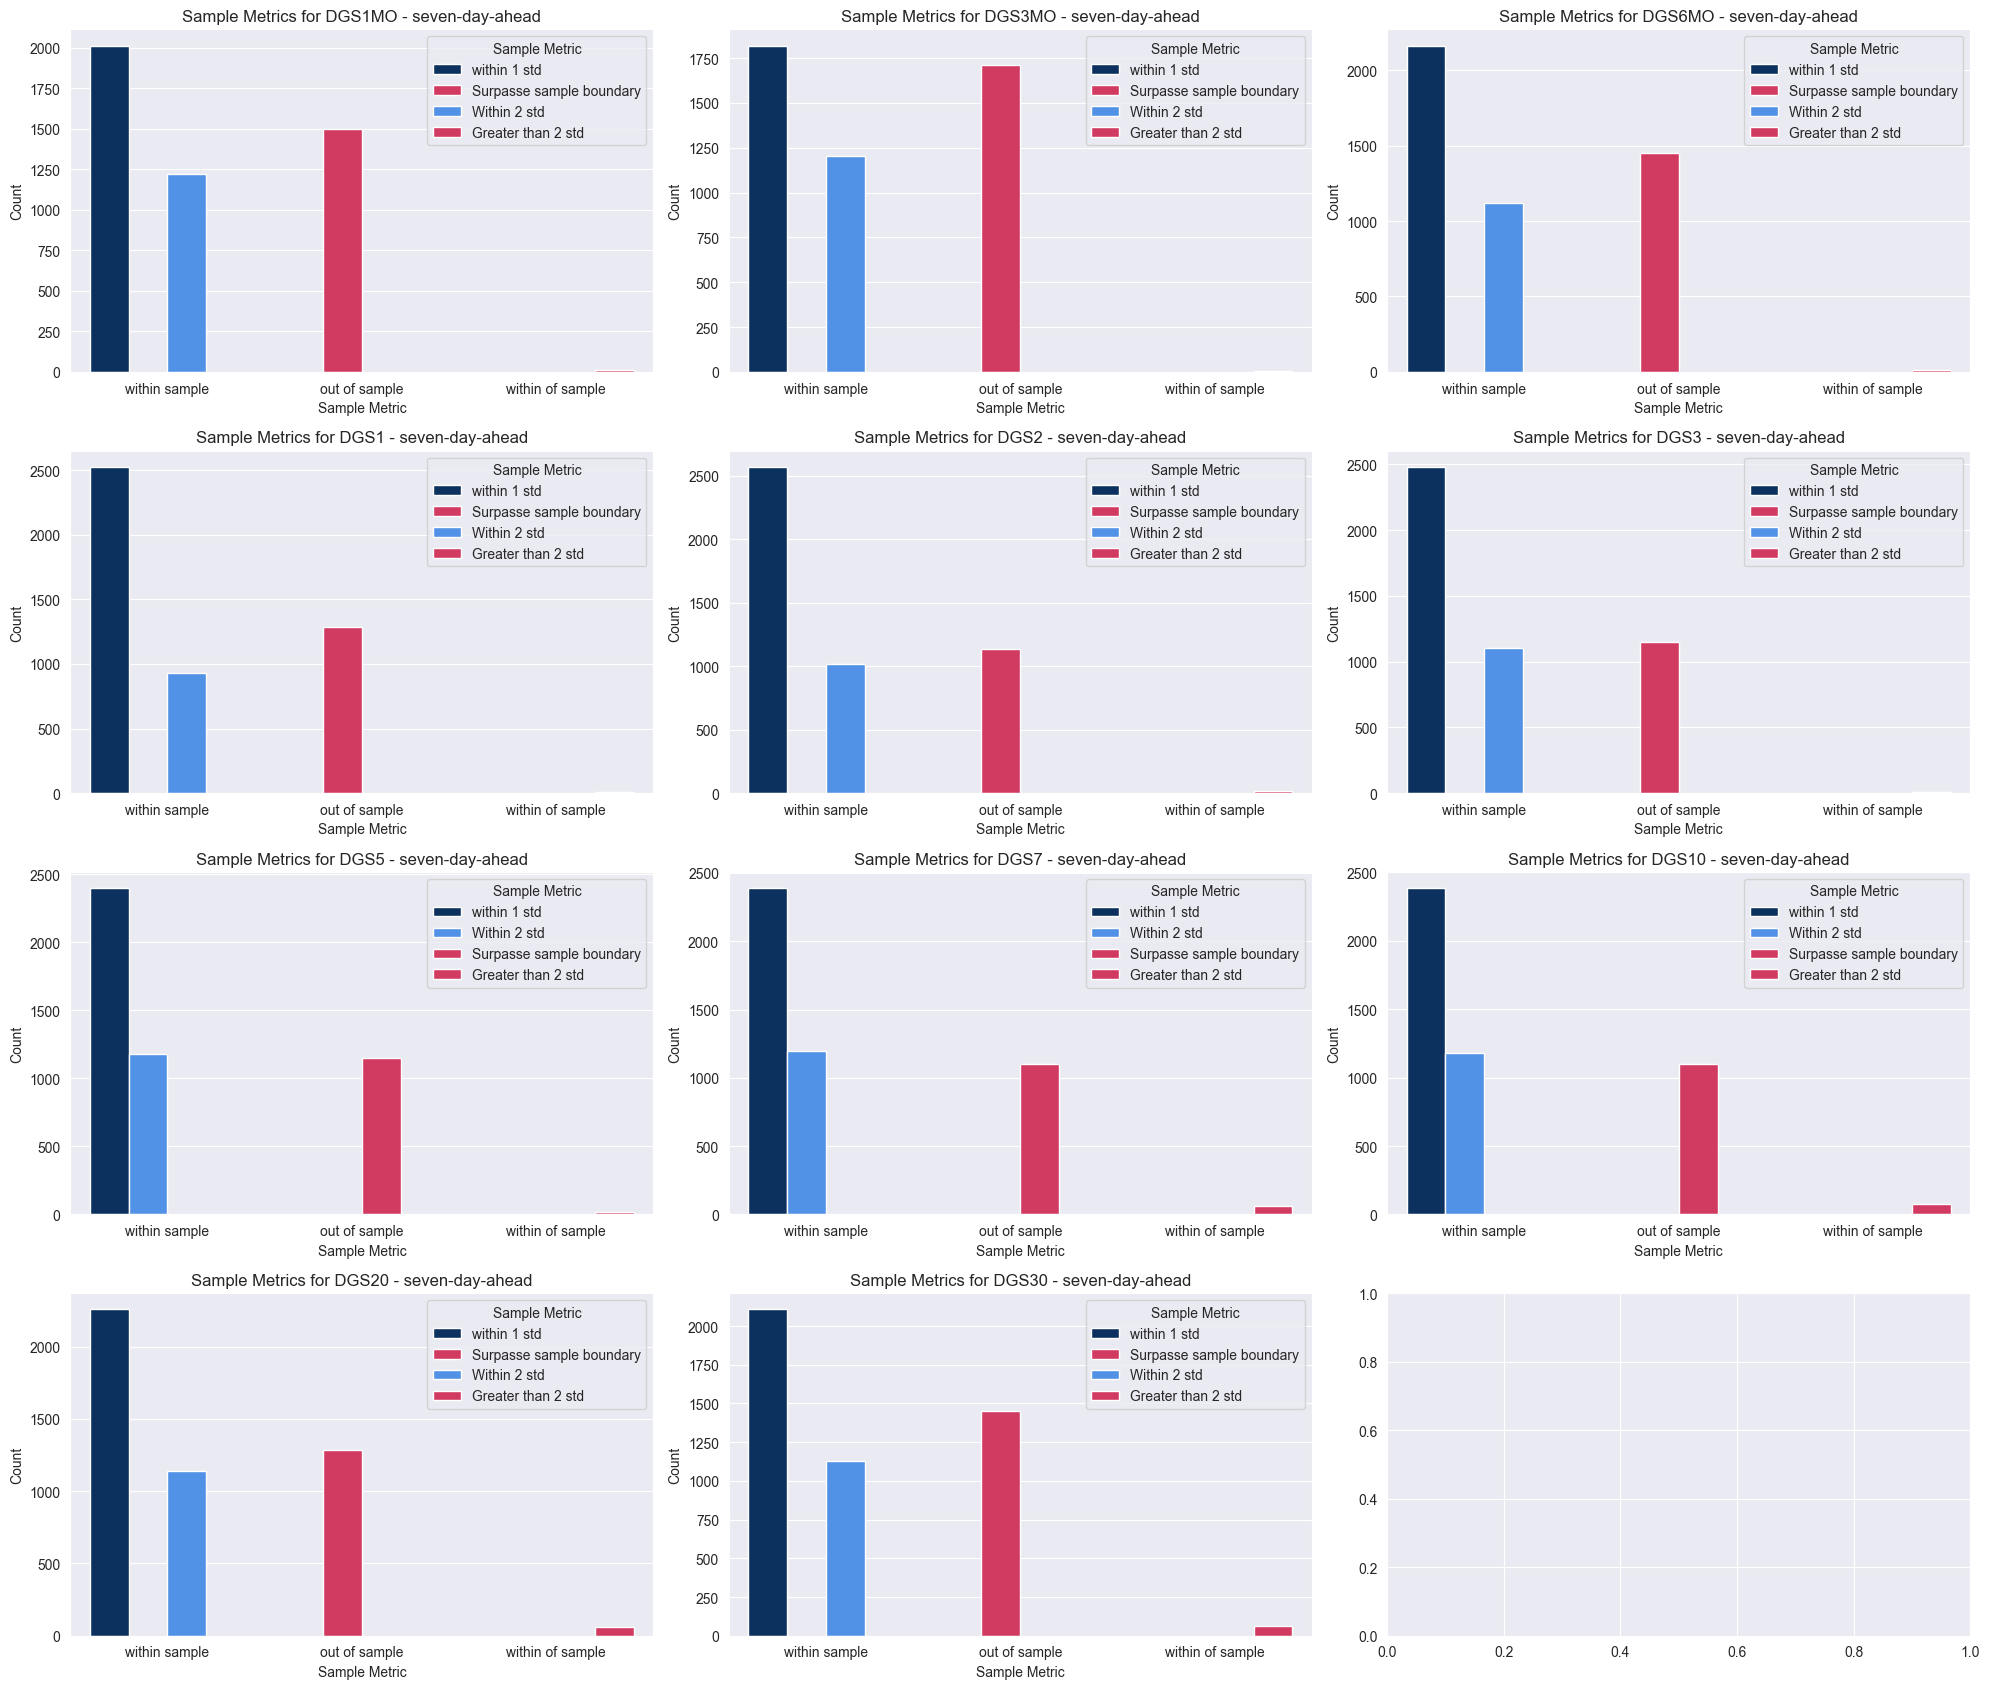

In [5]:
plot_sample_metrics()
# metric_forecaster.forecasts_df[[f"DGS1MO_sample_range", f"DGS1MO_sample_metric"]].value_counts().reset_index()

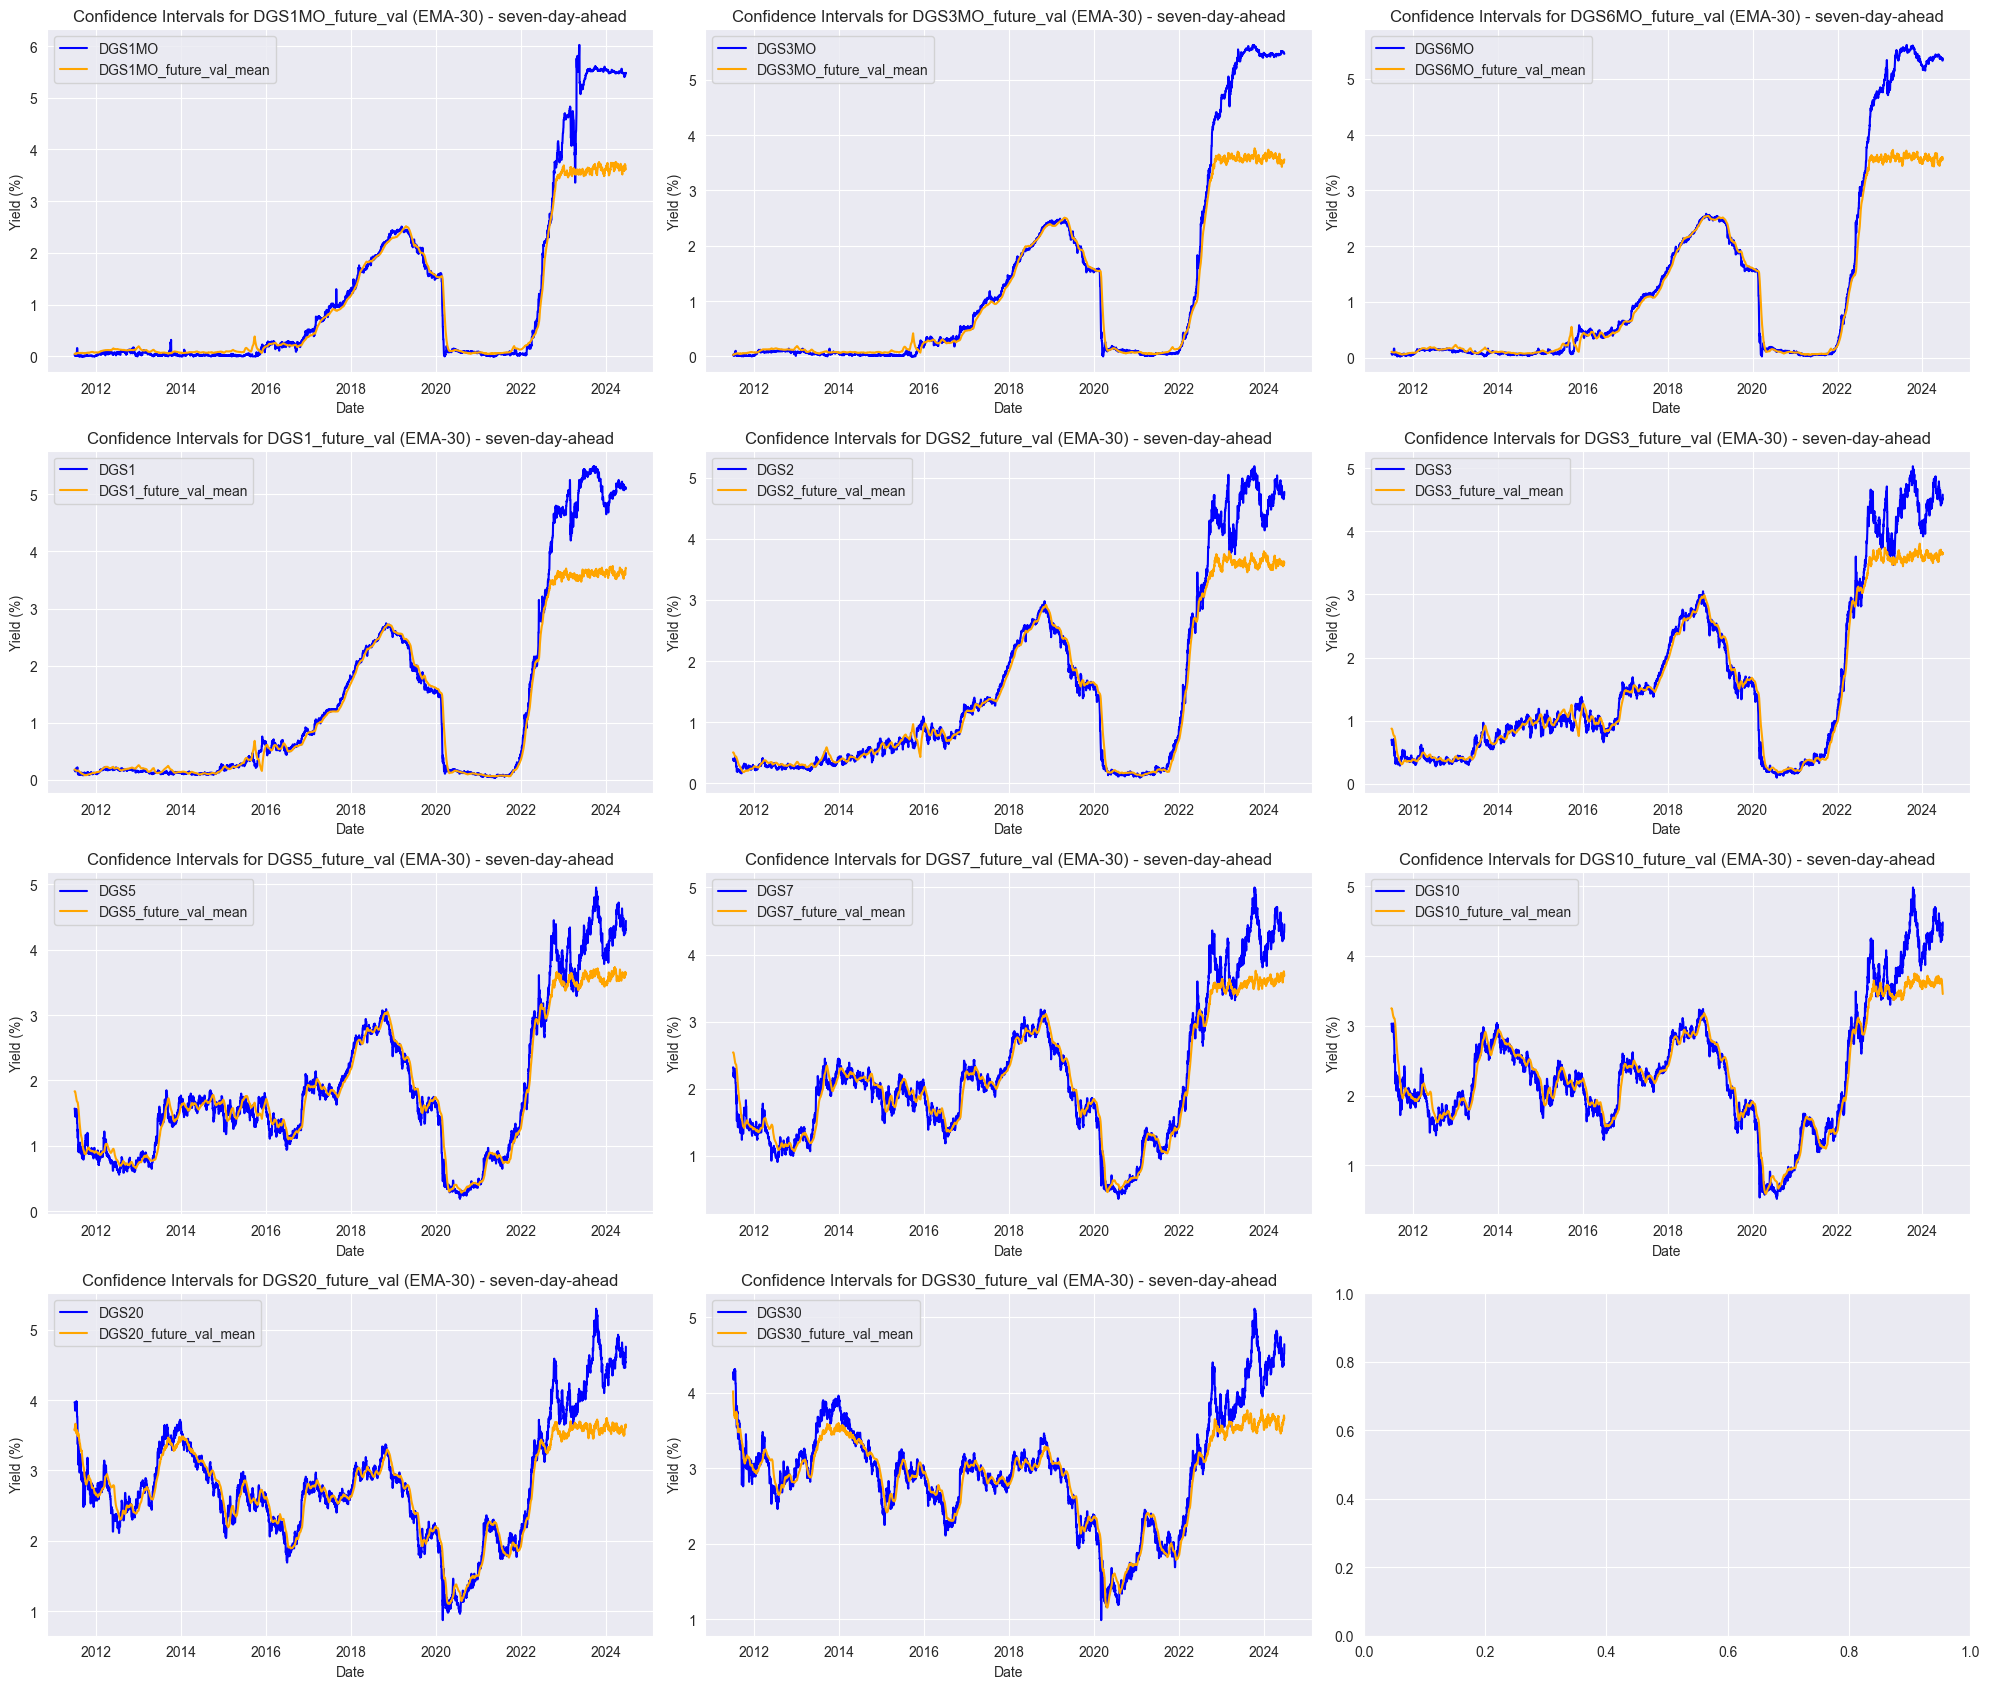

In [6]:
metric_forecaster.plot_time_confidence_intervals(train=False, confidence_bands=False, smoothing=True, save_fig=False, smoothing_window=30)

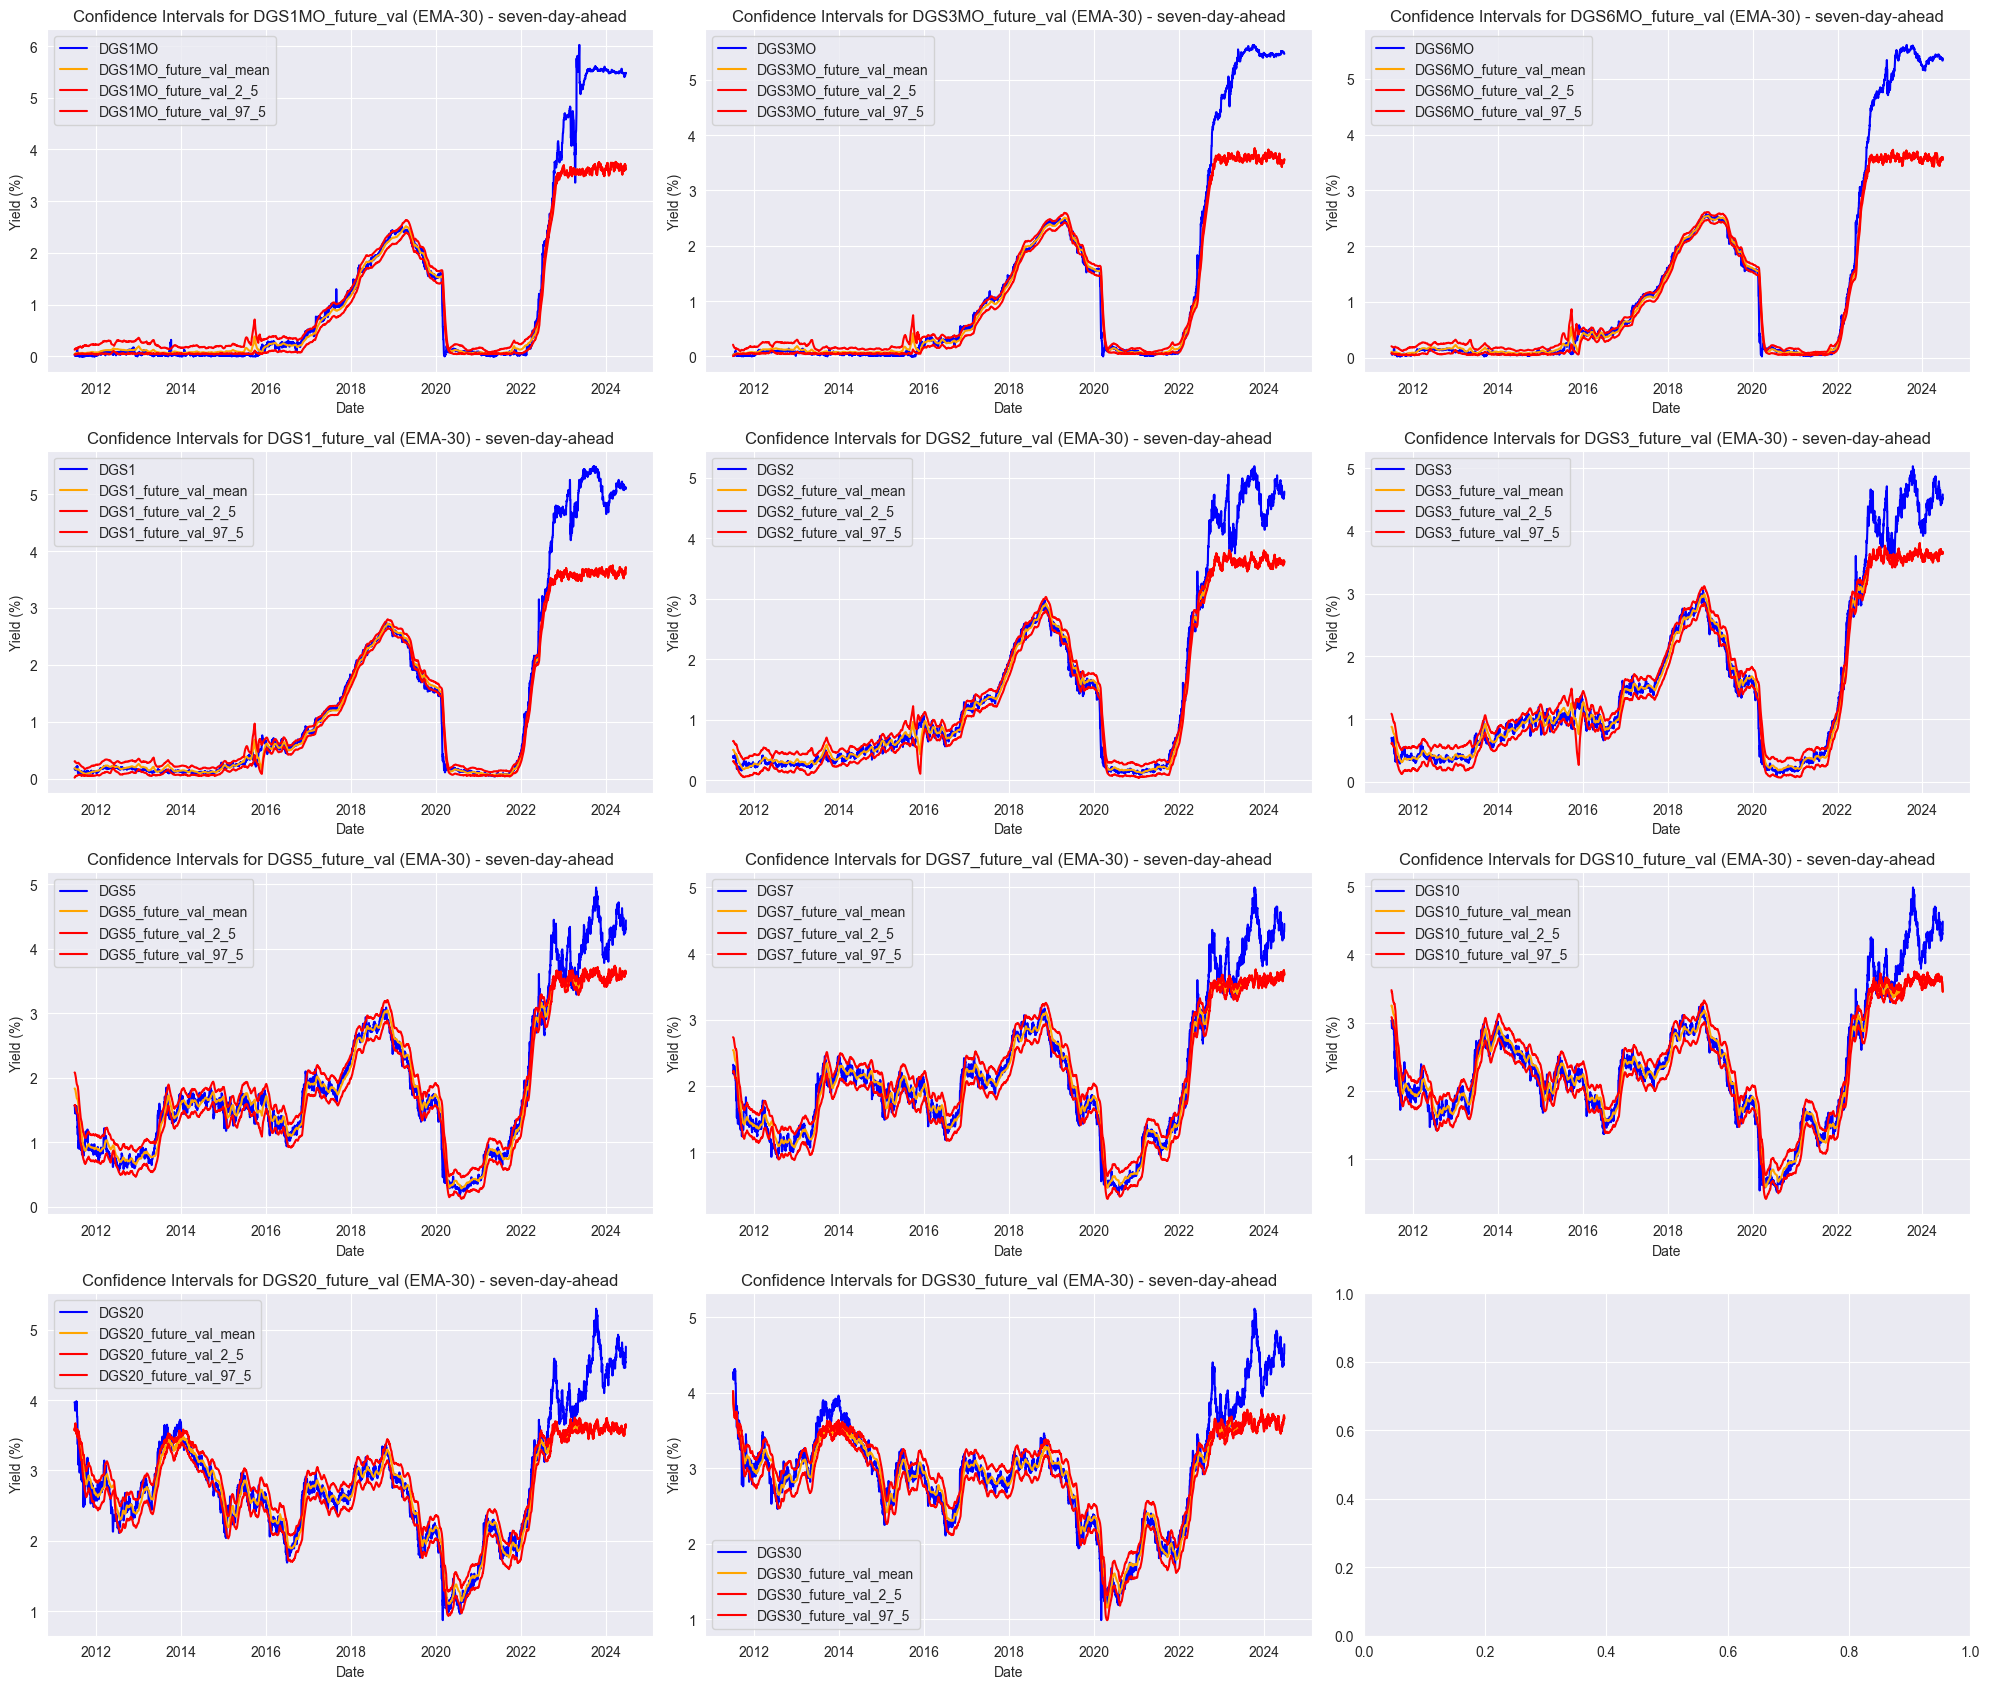

In [7]:
metric_forecaster.plot_time_confidence_intervals(train=False, confidence_bands=True, smoothing=True, save_fig=False, smoothing_window=30)

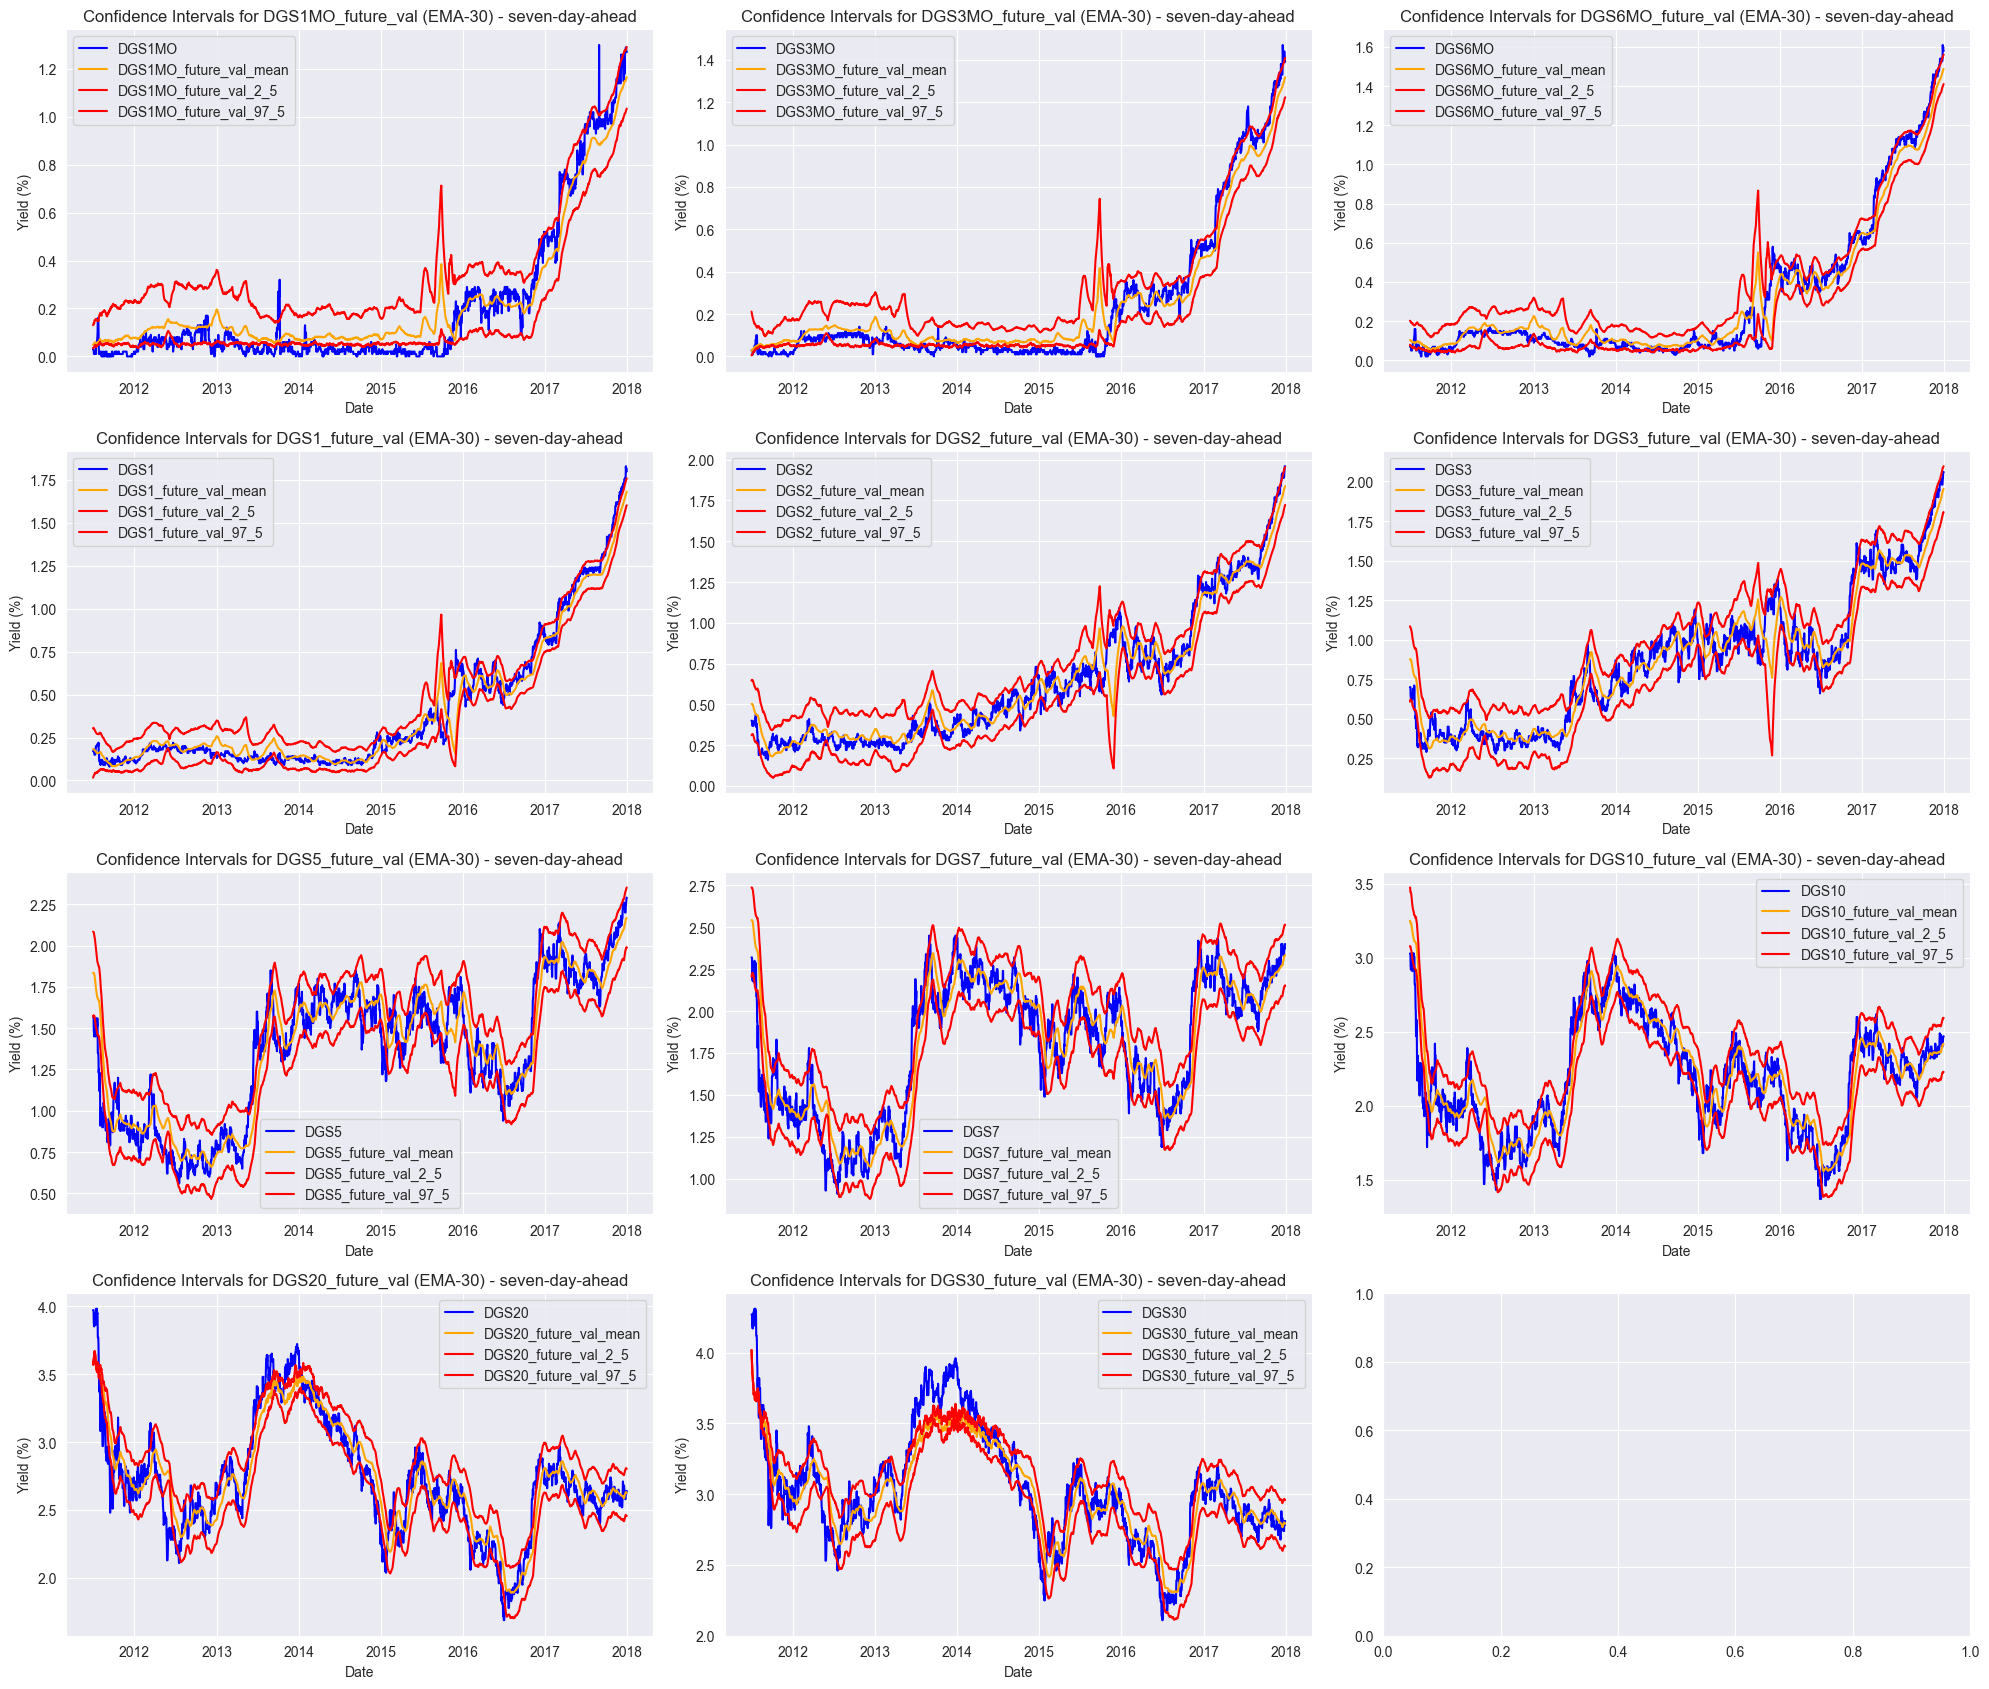

In [8]:
metric_forecaster.plot_time_confidence_intervals(train=True, confidence_bands=True, smoothing=True, save_fig=False, smoothing_window=30)